In [3]:
# !pip install pandas plotly matplotlib seaborn nbformat scikit-learn  pyarrow==14.0.2 --upgrade --quiet

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn import preprocessing
from urllib.request import urlretrieve
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
%matplotlib inline

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

**Reading values from Parquet**

In [5]:
train_inputs=pd.read_parquet('train_inputs.parquet')
val_inputs=pd.read_parquet('val_inputs.parquet')
test_inputs=pd.read_parquet('test_inputs.parquet')

X_train=pd.read_parquet('X_train.parquet')
X_val=pd.read_parquet('X_val.parquet')
X_test=pd.read_parquet('X_test.parquet')

train_targets=pd.read_parquet('train_targets.parquet')['RainTomorrow']
val_targets=pd.read_parquet('val_targets.parquet')['RainTomorrow']
test_targets=pd.read_parquet('test_targets.parquet')['RainTomorrow']

In [6]:
print('train_inputs: ',train_inputs.shape)
print('train_targets: ',train_targets.shape)
print('X_train: ',X_train.shape)
print('val_inputs: ',val_inputs.shape)
print('val_targets: ',val_targets.shape)
print('X_val: ',X_val.shape)
print('test_inputs: ',test_inputs.shape)
print('test_targets: ',test_targets.shape)
print('Xtest.shape: ',X_test.shape)

train_inputs:  (98988, 124)
train_targets:  (98988,)
X_train:  (98988, 119)
val_inputs:  (17231, 124)
val_targets:  (17231,)
X_val:  (17231, 119)
test_inputs:  (25974, 124)
test_targets:  (25974,)
Xtest.shape:  (25974, 119)


**Training and Visualization of Decision Tree**

In [7]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)

In [8]:
model.fit(X_train,train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
train_preds=model.predict(X_train)
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(98988,), dtype=object)

In [10]:
pd.value_counts(train_preds)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21384\1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


No     76707
Yes    22281
Name: count, dtype: int64

In [11]:
train_probs=model.predict_proba(X_train)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(98988, 2))

In [12]:
from sklearn.metrics import accuracy_score,confusion_matrix
acc=accuracy_score(train_preds,train_targets)
acc

0.9999797955307714

Text(0.5, 1.0, 'train Confusion Matrix')

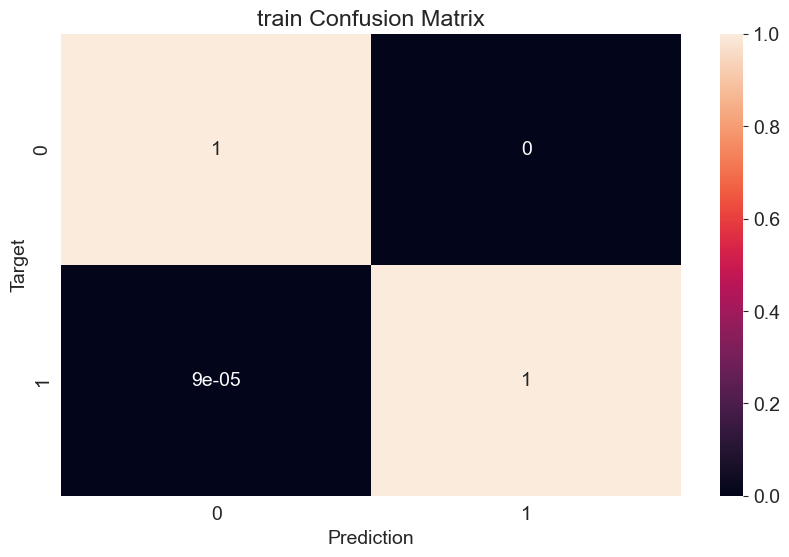

In [13]:
cf=confusion_matrix(train_targets,train_preds,normalize='true')
plt.figure()
sns.heatmap(cf,annot=True)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.title('{} Confusion Matrix'.format('train'))

**Testing Using validations and testing data**

In [14]:
val_preds=model.predict(X_val)
test_preds=model.predict(X_test)
print('accuracy of validation: ',model.score(X_val,val_targets))
print('accuracy of test: ',model.score(X_test,test_targets))

accuracy of validation:  0.7921188555510418
accuracy of test:  0.7741202741202741


In [15]:
print('train_inputs: ',train_inputs.shape)
print('train_targets: ',train_targets.shape)
print('val_inputs: ',val_inputs.shape)
print('val_targets: ',val_targets.shape)
print('test_inputs: ',test_inputs.shape)
print('test_targets: ',test_targets.shape)

train_inputs:  (98988, 124)
train_targets:  (98988,)
val_inputs:  (17231, 124)
val_targets:  (17231,)
test_inputs:  (25974, 124)
test_targets:  (25974,)


0.7921188555510418


Text(0.5, 1.0, 'validation Confusion Matrix')

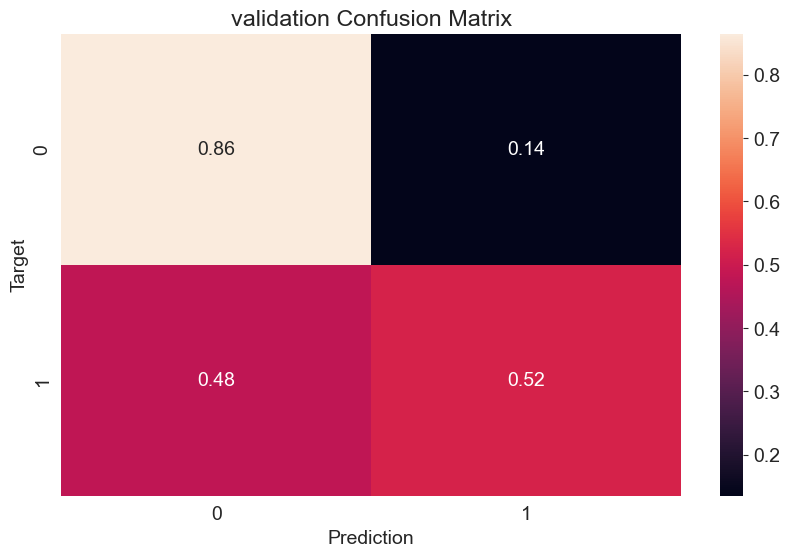

In [16]:
cf=confusion_matrix(val_targets,val_preds,normalize='true')
print(accuracy_score(val_targets,val_preds))
plt.figure()
sns.heatmap(cf,annot=True)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.title('{} Confusion Matrix'.format('validation'))

0.7741202741202741


Text(0.5, 1.0, 'test Confusion Matrix')

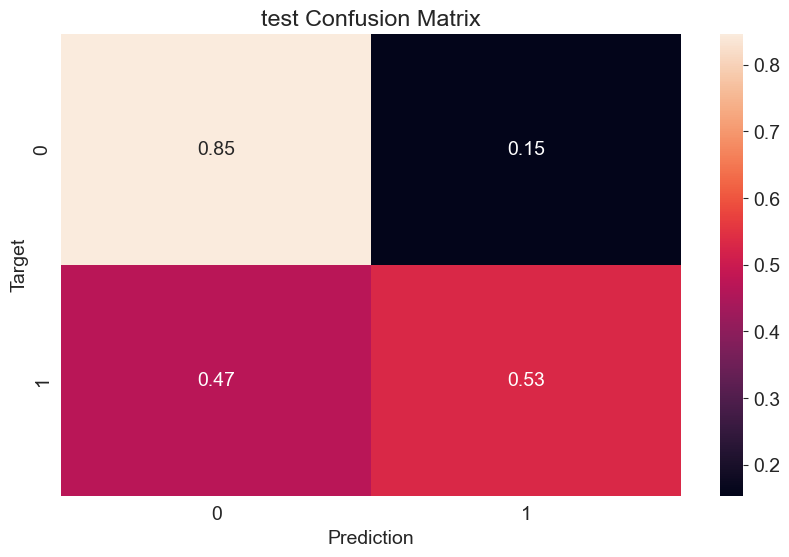

In [17]:
cf=confusion_matrix(test_targets,test_preds,normalize='true')
print(accuracy_score(test_targets,test_preds))
plt.figure()
sns.heatmap(cf,annot=True)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.title('{} Confusion Matrix'.format('test'))

**Visualize tree**

[Text(0.5, 0.9285714285714286, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.7857142857142857, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.5, 'Pressure3pm <= 0.583\ngini = 0.363\nsamples = 12620\nvalue = [9618, 3002]'),
 Text(0.03125, 0.35714285714285715, 'WindGustSpeed <= 0.364\ngini = 0.469\nsamples = 4691\nvalue = [2932, 1759]'),
 Text(0.015625, 0.21428571428571427, 'Humidity3pm <= 0.275\ngini = 0.435\nsamples = 3251\nvalue = [2210, 1041]'),
 Text(0.0078125, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.0234375, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.046875, 0.21428571428571427, 'Humidity3pm <= 0.455\ngini = 0.5\nsamples = 1440\nvalue = [722, 718]'),
 Text(0.0390625, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.0546875

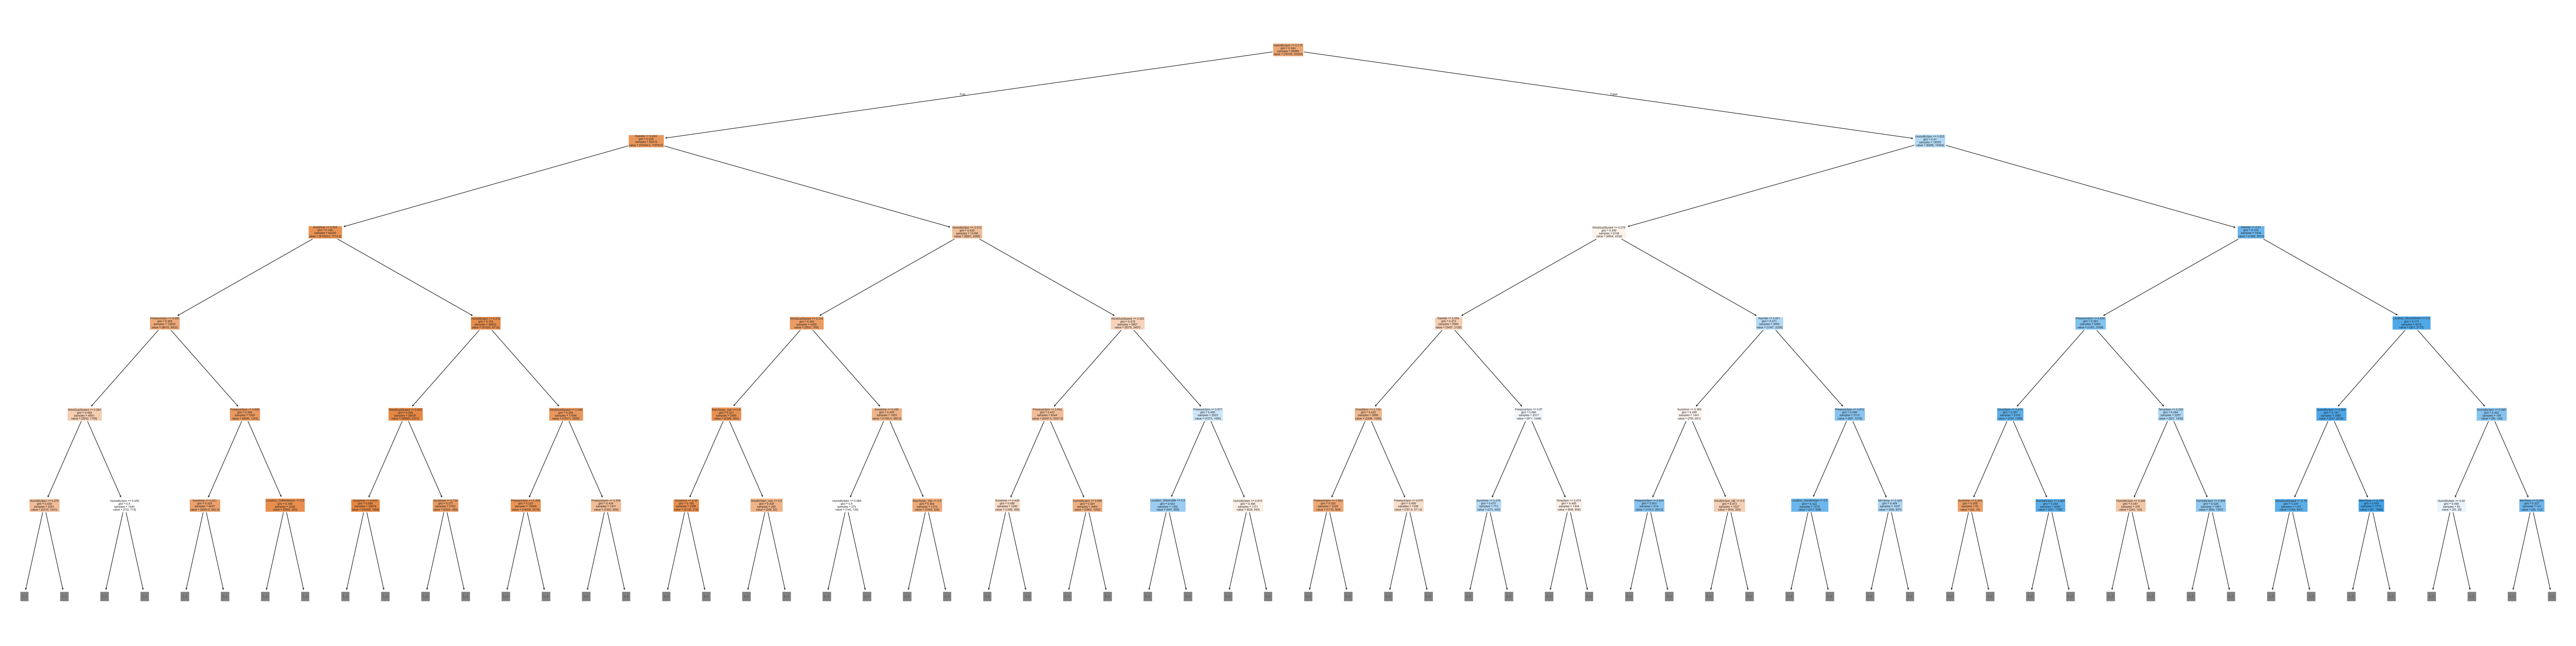

In [18]:
from sklearn.tree import plot_tree,export_text
plt.figure(figsize=(80,20))
plot_tree(model,feature_names=X_train.columns,max_depth=5,filled=True)

In [19]:
model.tree_.max_depth

48

In [20]:
tree_test=export_text(model,max_depth=10,feature_names=list(X_train.columns))
print(tree_test[:5000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

In [21]:
result_df=pd.DataFrame({
    'features':X_train.columns,
    'importance':model.feature_importances_
})
result_df

,features,importance
0,MinTemp,0.034894
1,MaxTemp,0.032361
2,Rainfall,0.059139
3,Evaporation,0.024962
4,Sunshine,0.049465
5,WindGustSpeed,0.056333
6,WindSpeed9am,0.028021
7,WindSpeed3pm,0.029813
8,Humidity9am,0.040218
9,Humidity3pm,0.261441


<Axes: xlabel='importance', ylabel='features'>

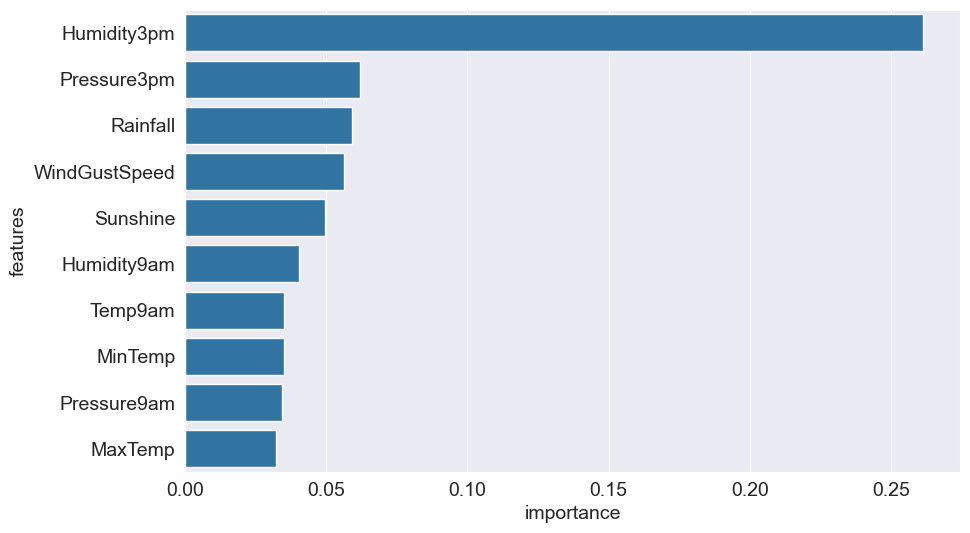

In [22]:
sns.barplot(result_df.sort_values('importance',ascending=False).head(10),x='importance',y='features')

**Training with fixed hyperparameter**

In [23]:
model2=DecisionTreeClassifier(max_depth=6,random_state=42).fit(X_train,train_targets)

In [24]:
train_preds=model2.predict(X_train)
val_preds=model2.predict(X_val)
test_preds=model2.predict(X_test)
print('accuracy of training: ',model2.score(X_train,train_targets))
print('accuracy of validation: ',model2.score(X_val,val_targets))
print('accuracy of test: ',model2.score(X_test,test_targets))

accuracy of training:  0.8437285327514447
accuracy of validation:  0.8427253206430271
accuracy of test:  0.8303303303303303


In [27]:
plt.figure(figsize=(150,80))
plot_tree(model2,feature_names=X_train.columns,filled=True,rounded=True, class_names=model2.classes_)

[Text(0.5, 0.9285714285714286, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]\nclass = No'),
 Text(0.25, 0.7857142857142857, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]\nclass = No'),
 Text(0.375, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]\nclass = No'),
 Text(0.0625, 0.5, 'Pressure3pm <= 0.583\ngini = 0.363\nsamples = 12620\nvalue = [9618, 3002]\nclass = No'),
 Text(0.03125, 0.35714285714285715, 'WindGustSpeed <= 0.364\ngini = 0.469\nsamples = 4691\nvalue = [2932, 1759]\nclass = No'),
 Text(0.015625, 0.21428571428571427, 'Humidity3pm <= 0.275\ngini = 0.435\nsamples = 3251\nvalue = [2210, 1041]\nclass = No'),
 Text(0.0078125, 0.07142857142857142, 'gini = 0.161\nsamples = 272\nvalue = [248, 24]\nclass = No'),
 Text(0.0234375, 0.07142857142857142, 'gini = 0.45\nsamples = 2979\nvalue = [1962.0, 1017.0]\nclass = No'),
 Text(0.0468

In [28]:
tree_test=export_text(model2,feature_names=list(X_train.columns))
print(tree_test)

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |--- WindGustSpeed >  0.36
|   |   |   |   |   |--- Humidity3pm <= 0.45
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.45
|   |   |   |   |   |   |--- class: Yes
|   |   |   |--- Pressure3pm >  0.58
|   |   |   |   |--- Pressure3pm <= 0.70
|   |   |   |   |   |--- Sunshine <= 0.32
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Sunshine >  0.32
|   |   |   |   |   |   |--- class: No
|   |   |   |   |--- Pressure3pm >  0.70
|   |   |   |   |   |--- Location_CoffsHarbour <= 0.50
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Location_CoffsHarbour >  0.50
|   |   |   |   |   |   |--- 